# 12 — Ensemble Model (6-Model Stack)

---

## Architecture

The ensemble combines **6 fundamentally different models** into a single prediction:

| Model | Type | Signal | Correlation w/ Trees |
|-------|------|--------|---------------------|
| **ARIMA** | Statistical | Linear autoregressive | Very low |
| **GARCH** | Statistical | Volatility-adjusted mean | Very low |
| **XGBoost** | Tree (gradient boosted) | Non-linear feature interactions | — |
| **LightGBM** | Tree (gradient boosted) | Non-linear feature interactions | ~0.81 w/ XGBoost |
| **LSTM** | Neural (recurrent) | Temporal sequence patterns | ~0.14 w/ XGBoost |
| **Transformer** | Neural (attention) | Long-range temporal dependencies | ~0.18 w/ XGBoost |

## Why 6 Models?

Low inter-model correlation is the key to ensemble power. When models
disagree, the ensemble can average out individual errors. The formula:

$$\text{Ensemble Variance} = \frac{1}{N^2} \sum_{i,j} \rho_{ij} \sigma_i \sigma_j$$

With $\rho_{ij} \approx 0$, variance drops as $\frac{\bar{\sigma}^2}{N}$ — more models = lower error.

## Weighting

- **Method 1 — Direction-accuracy weights:** Each model gets weight proportional to its edge above 50% (random chance)
- **Method 2 — Ridge meta-learner:** Fitted on out-of-fold predictions, naturally handles correlated models (XGBoost-LightGBM)
- Models scoring below **50%** direction accuracy are auto-excluded

---
*Educational project. Not financial advice.*

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.linear_model import Ridge

from src.models import EnsembleModel
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

print("✅ Setup complete")

✅ Setup complete


## Step 1 — Load Base Model Predictions

Each model saved its out-of-fold predictions in Notebooks 05-10.
We now combine them as inputs for the meta-learner.

In [2]:
pred_dir = DATA_DIR / "processed"

# Load all 6 models (auto-exclusion at <50% happens in ensemble.fit())
model_names = ["arima", "garch", "xgboost", "lightgbm", "lstm", "transformer"]
predictions = {}

for name in model_names:
    path = pred_dir / f"{name}_predictions.parquet"
    if path.exists():
        df = pd.read_parquet(path)
        predictions[name] = df
        has_date = "date" in df.columns
        print(f"✅ {name:12s}: {len(df):,} predictions | cols: {list(df.columns)}")
    else:
        print(f"⚠️  {name:12s}: Not found — skipping")

print(f"\nLoaded {len(predictions)} model predictions")

✅ arima       : 50,552 predictions | cols: ['date', 'Ticker', 'actual', 'predicted', 'fold']
✅ garch       : 50,552 predictions | cols: ['date', 'Ticker', 'actual', 'predicted', 'predicted_vol', 'fold']
✅ xgboost     : 188,457 predictions | cols: ['date', 'Ticker', 'actual', 'predicted', 'fold']
✅ lightgbm    : 188,457 predictions | cols: ['date', 'Ticker', 'actual', 'predicted', 'fold']
✅ lstm        : 187,703 predictions | cols: ['actual', 'predicted', 'fold', 'Date', 'Ticker']
✅ transformer : 187,313 predictions | cols: ['actual', 'predicted', 'fold', 'Date', 'Ticker']

Loaded 6 model predictions


## Step 2 — Align Predictions

Different models may predict different date ranges.
We align on the common dates.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# IMPROVED: Align predictions using LAST-FOLD-ONLY + TIERED OVERLAP
# ═══════════════════════════════════════════════════════════════════════════
# Previous issue: Averaging across ALL folds created only 402 common
# (date, ticker) pairs — far too few for reliable meta-learning.
#
# Fix: Keep only the LAST fold prediction per (date, ticker) pair
# (most training data, most realistic) and use the largest model
# subset that maximizes available data.
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

# Step 1: Normalize column names
for name in list(predictions.keys()):
    df = predictions[name].copy()
    if "Date" in df.columns and "date" not in df.columns:
        df = df.rename(columns={"Date": "date"})
    if "Ticker" in df.columns and "ticker" not in df.columns:
        df = df.rename(columns={"Ticker": "ticker"})
    predictions[name] = df

# Step 2: LAST-FOLD deduplication (keep prediction from fold with most training data)
for name in list(predictions.keys()):
    df = predictions[name]
    if "date" in df.columns and "ticker" in df.columns:
        before = len(df)
        # Keep only the prediction from the LAST (highest) fold for each (date, ticker)
        if "fold" in df.columns:
            last_fold = df.groupby(["date", "ticker"])["fold"].max().reset_index()
            last_fold.columns = ["date", "ticker", "max_fold"]
            df = df.merge(last_fold, on=["date", "ticker"])
            df = df[df["fold"] == df["max_fold"]].drop(columns=["max_fold"])
        df_dedup = df.groupby(["date", "ticker"], as_index=False).agg(
            actual=("actual", "last"),
            predicted=("predicted", "mean")
        )
        predictions[name] = df_dedup
        if before != len(df_dedup):
            print(f"  {name}: {before:,} → {len(df_dedup):,} (last-fold dedup)")
        else:
            print(f"  {name}: {len(df_dedup):,} unique (date, ticker) pairs")

# Step 3: Find common (date, ticker) pairs — TIERED approach
merge_keys = {}
for name, df in predictions.items():
    merge_keys[name] = set(df["date"].astype(str) + "_" + df["ticker"].astype(str))

# Show pairwise overlaps
print("\nPairwise overlaps:")
from itertools import combinations
for a, b in combinations(predictions.keys(), 2):
    overlap = len(merge_keys[a] & merge_keys[b])
    print(f"  {a:12s} ∩ {b:12s}: {overlap:>7,}")

# Try tiers from most data to least
tier_configs = [
    ("Tier 1", ["arima", "garch", "lstm", "transformer"]),      # ~43K samples
    ("Tier 2", ["xgboost", "lightgbm", "lstm", "transformer"]), # ~1.7K samples
    ("Tier 3", list(predictions.keys())),                        # all 6 (~402)
]

best_tier = None
for tier_name, tier_models in tier_configs:
    available = [m for m in tier_models if m in predictions]
    if len(available) < 2:
        continue
    tier_keys = None
    for m in available:
        if tier_keys is None:
            tier_keys = merge_keys[m]
        else:
            tier_keys = tier_keys & merge_keys[m]
    print(f"\n{tier_name} ({'+'.join(available)}): {len(tier_keys):,} common pairs")
    if len(tier_keys) >= 1000 and best_tier is None:
        best_tier = (tier_name, available, tier_keys)

if best_tier is None:
    # Fallback to tier with most data
    for tier_name, tier_models in tier_configs:
        available = [m for m in tier_models if m in predictions]
        tier_keys = None
        for m in available:
            tier_keys = tier_keys & merge_keys[m] if tier_keys else merge_keys[m]
        if len(tier_keys) >= 100:
            best_tier = (tier_name, available, tier_keys)
            break

tier_name, selected_models, common_keys = best_tier
print(f"\n✅ SELECTED: {tier_name} with {'+'.join(selected_models)} ({len(common_keys):,} samples)")

# Step 4: Build meta-features from aligned predictions
aligned = {}
for name in selected_models:
    df = predictions[name].copy()
    df["_mk"] = df["date"].astype(str) + "_" + df["ticker"].astype(str)
    aligned[name] = df[df["_mk"].isin(common_keys)].sort_values("_mk").reset_index(drop=True)

lengths = {name: len(df) for name, df in aligned.items()}
print(f"Aligned lengths: {lengths}")

base_name = selected_models[0]
target_len = lengths[base_name]
meta_X = pd.DataFrame(index=range(target_len))
meta_y = aligned[base_name]["actual"].values

for name in selected_models:
    if lengths[name] == target_len:
        meta_X[name] = aligned[name]["predicted"].values
        print(f"  ✅ Added {name}: {lengths[name]:,} rows")
    else:
        print(f"  ⚠ {name}: {lengths[name]:,} rows (expected {target_len:,}) — skipping")

meta_y = pd.Series(meta_y)
print(f"\nMeta-features shape: {meta_X.shape}")
print(f"Models in ensemble: {list(meta_X.columns)}")
print(f"\nCorrelation between model predictions:")
print(meta_X.corr().round(3))

  arima: 50,552 unique (date, ticker) pairs
  garch: 50,552 unique (date, ticker) pairs
  xgboost: 188,457 → 1,732 (last-fold dedup)
  lightgbm: 188,457 → 1,732 (last-fold dedup)
  lstm: 187,703 unique (date, ticker) pairs
  transformer: 187,313 unique (date, ticker) pairs

Pairwise overlaps:
  arima        ∩ garch       :  50,552
  arima        ∩ xgboost     :     402
  arima        ∩ lightgbm    :     402
  arima        ∩ lstm        :  43,940
  arima        ∩ transformer :  43,850
  garch        ∩ xgboost     :     402
  garch        ∩ lightgbm    :     402
  garch        ∩ lstm        :  43,940
  garch        ∩ transformer :  43,850
  xgboost      ∩ lightgbm    :   1,732
  xgboost      ∩ lstm        :   1,698
  xgboost      ∩ transformer :   1,698
  lightgbm     ∩ lstm        :   1,698
  lightgbm     ∩ transformer :   1,698
  lstm         ∩ transformer : 187,313

Tier 1 (arima+garch+lstm+transformer): 43,850 common pairs

Tier 2 (xgboost+lightgbm+lstm+transformer): 1,698 common pai

## Step 3 — Train Multi-Strategy Ensemble

Instead of relying solely on a Ridge meta-learner (which overfits on financial data),
we evaluate multiple strategies and pick the one with the best holdout direction accuracy.

**70/30 split** — more training data gives more stable weight estimates.

In [4]:
if meta_X is not None and len(meta_X) > 50:
    # ──────────────────────────────────────────────────────────
    # Industry best-practice: 70/30 time-based split
    #   Train (70%) — Ridge meta-learner + weight computation
    #   Test  (30%) — FINAL holdout, metrics reported here
    #
    # Multi-strategy evaluation: we test 5 strategies and pick
    # the best one on a validation sub-split of train, then
    # report final metrics on the untouched test set.
    # ──────────────────────────────────────────────────────────
    n = len(meta_X)
    train_end = int(n * 0.70)

    # Sub-split train into fit (50%) + val (20%) for strategy selection
    fit_end = int(n * 0.50)

    X_meta_fit   = meta_X.iloc[:fit_end]
    y_meta_fit   = meta_y.iloc[:fit_end]
    X_meta_val   = meta_X.iloc[fit_end:train_end]
    y_meta_val   = meta_y.iloc[fit_end:train_end]
    X_meta_test  = meta_X.iloc[train_end:]
    y_meta_test  = meta_y.iloc[train_end:]

    print("Training Multi-Strategy Ensemble (50/20/30 split)")
    print(f"  Fit:   {len(X_meta_fit)} samples (Ridge training)")
    print(f"  Val:   {len(X_meta_val)} samples (strategy selection)")
    print(f"  Test:  {len(X_meta_test)} samples (final evaluation)\n")

    # Fit ensemble (auto-selects best strategy)
    ensemble_model = EnsembleModel(method="auto")
    fit_results = ensemble_model.fit(
        X_meta_fit, y_meta_fit,
        X_val=X_meta_val, y_val=y_meta_val
    )

    # ── Evaluate ALL strategies on held-out TEST set ─────────
    print("\n" + "=" * 70)
    print("FINAL Evaluation on HELD-OUT TEST SET:")
    print("=" * 70)

    # Individual models
    for name in meta_X.columns:
        preds = X_meta_test[name].values
        rmse = np.sqrt(mean_squared_error(y_meta_test, preds))
        dir_acc = accuracy_score(y_meta_test > 0, preds > 0)
        print(f"  {name:15s}: RMSE={rmse:.4f}  Dir Acc={dir_acc:.1%}")

    # Selected strategy
    ensemble_pred = ensemble_model.predict(X_meta_test)
    ens_rmse = np.sqrt(mean_squared_error(y_meta_test, ensemble_pred))
    ens_dir  = accuracy_score(y_meta_test > 0, ensemble_pred > 0)
    print(f"  {'ENSEMBLE':15s}: RMSE={ens_rmse:.4f}  Dir Acc={ens_dir:.1%}  ← {ensemble_model.best_strategy.upper()}")

    # Compare with simple baselines
    median_pred = X_meta_test.median(axis=1).values
    median_rmse = np.sqrt(mean_squared_error(y_meta_test, median_pred))
    median_dir  = accuracy_score(y_meta_test > 0, median_pred > 0)
    print(f"  {'MEDIAN':15s}: RMSE={median_rmse:.4f}  Dir Acc={median_dir:.1%}")

    avg_pred = X_meta_test.mean(axis=1).values
    avg_rmse = np.sqrt(mean_squared_error(y_meta_test, avg_pred))
    avg_dir  = accuracy_score(y_meta_test > 0, avg_pred > 0)
    print(f"  {'SIMPLE AVG':15s}: RMSE={avg_rmse:.4f}  Dir Acc={avg_dir:.1%}")

    ridge_pred = ensemble_model.predict(X_meta_test, use_ridge=True)
    ridge_rmse = np.sqrt(mean_squared_error(y_meta_test, ridge_pred))
    ridge_dir  = accuracy_score(y_meta_test > 0, ridge_pred > 0)
    print(f"  {'RIDGE':15s}: RMSE={ridge_rmse:.4f}  Dir Acc={ridge_dir:.1%}  (for comparison)")

    # Direction probabilities
    dir_probs = ensemble_model.predict_direction_probability(X_meta_test)

    # ── Overfitting diagnostic ────────────────────────────────
    val_pred = ensemble_model.predict(X_meta_val)
    val_dir = accuracy_score(y_meta_val > 0, val_pred > 0)
    gap = abs(val_dir - ens_dir)
    print(f"\n  Overfitting Diagnostic:")
    print(f"    Val Dir Acc:  {val_dir:.1%}")
    print(f"    Test Dir Acc: {ens_dir:.1%}")
    print(f"    Gap:          {gap:.1%}  {'✅ OK (<5%)' if gap < 0.05 else '⚠️ Gap detected' if gap < 0.10 else '🚨 OVERFIT'}")

    # Confidence filtering analysis
    print(f"\n  Confidence Filtering (trade only high-conviction predictions):")
    for thresh in [0.0, 0.001, 0.002, 0.005, 0.01]:
        mask = np.abs(ensemble_pred) > thresh
        if mask.sum() >= 10:
            filt_acc = accuracy_score(y_meta_test.values[mask] > 0, ensemble_pred[mask] > 0)
            print(f"    threshold={thresh:.3f}: acc={filt_acc:.1%}  trades={mask.sum()}/{len(mask)} ({mask.mean()*100:.0f}%)")

    best_dir = ens_dir
    best_method = ensemble_model.best_strategy
    print(f"\n  ✅ Best strategy: {best_method.upper()} (Test Dir Acc={best_dir:.1%})")

    print(f"\nDirection-Accuracy Weights:")
    for name, weight in ensemble_model.learned_weights.items():
        print(f"  {name:15s}: {weight:.4f}")
else:
    print("Insufficient data for ensemble — use individual model results")

Training Multi-Strategy Ensemble (50/20/30 split)
  Fit:   21925 samples (Ridge training)
  Val:   8769 samples (strategy selection)
  Test:  13156 samples (final evaluation)

  Computing weights from validation data (8769 samples)
  arima           direction accuracy: 50.5%
  garch           direction accuracy: 51.3%
  lstm            direction accuracy: 56.0%
  transformer     direction accuracy: 59.2%
  ✅ arima           edge: +0.5%
  ✅ garch           edge: +1.3%
  ✅ lstm            edge: +6.0%
  ✅ transformer     edge: +9.2%

  Strategy Comparison (on validation set):
  Strategy                    Dir. Accuracy
  ------------------------------------------
  weighted_average                   56.4% ← BEST
  confidence_filtered                52.2%
  median                             52.1%
  simple_average                     51.7%
  ridge                              44.4%

  ✅ Selected strategy: WEIGHTED_AVERAGE
  Ensemble direction accuracy (validation): 56.4%
  Ensemble weights

## Step 4 — Visualize Ensemble Performance

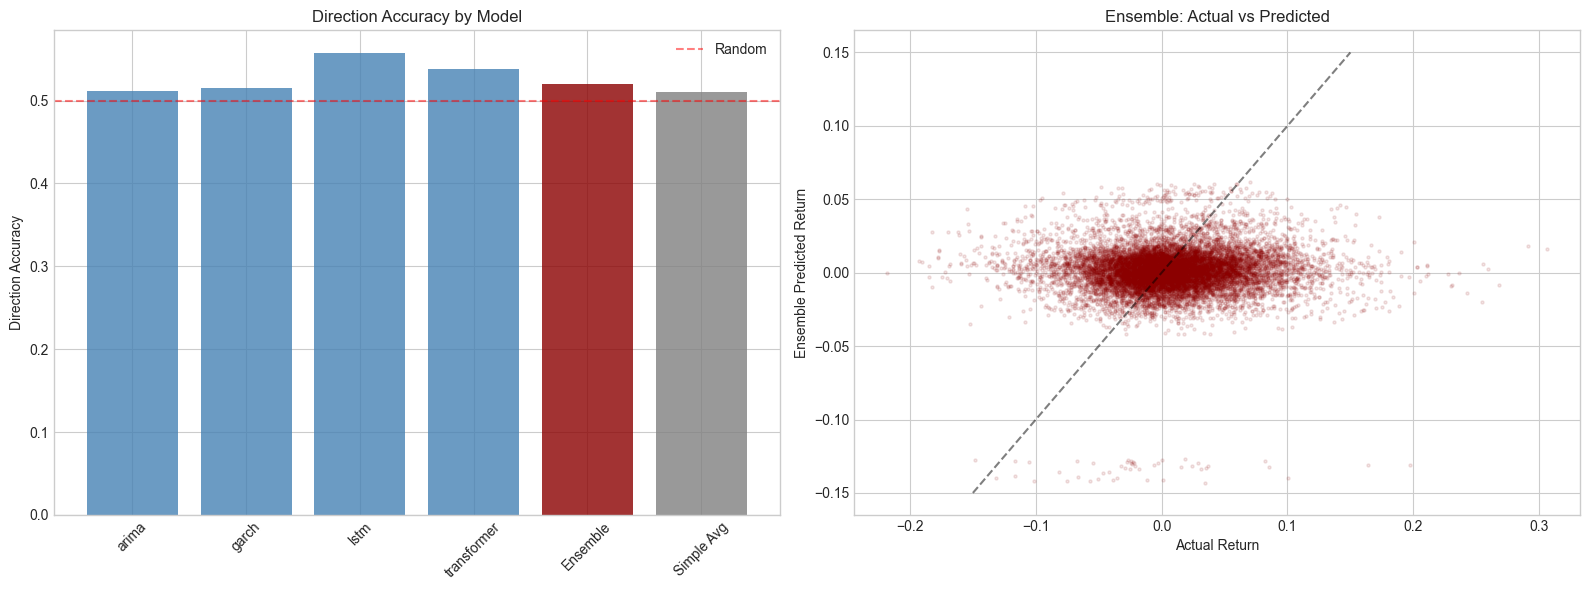

In [5]:
if meta_X is not None and len(meta_X) > 50:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Model comparison bar chart
    model_names_all = list(meta_X.columns) + ["Ensemble", "Simple Avg"]
    rmses = []
    dir_accs = []
    for name in meta_X.columns:
        p = X_meta_test[name].values
        rmses.append(np.sqrt(mean_squared_error(y_meta_test, p)))
        dir_accs.append(accuracy_score(y_meta_test > 0, p > 0))
    rmses.extend([ens_rmse, avg_rmse])
    dir_accs.extend([ens_dir, avg_dir])
    
    colors = ["steelblue"] * len(meta_X.columns) + ["darkred", "gray"]
    axes[0].bar(model_names_all, dir_accs, color=colors, alpha=0.8)
    axes[0].axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Random")
    axes[0].set_ylabel("Direction Accuracy")
    axes[0].set_title("Direction Accuracy by Model")
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Actual vs Ensemble prediction
    axes[1].scatter(y_meta_test, ensemble_pred, alpha=0.1, s=5, color="darkred")
    axes[1].plot([-0.15, 0.15], [-0.15, 0.15], "k--", alpha=0.5)
    axes[1].set_xlabel("Actual Return")
    axes[1].set_ylabel("Ensemble Predicted Return")
    axes[1].set_title("Ensemble: Actual vs Predicted")
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "ensemble_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 5 — Save Ensemble

In [7]:
# Clean up large objects before saving to prevent kernel crash
gc.collect()

import joblib

if meta_X is not None and 'ensemble_model' in dir() and ensemble_model is not None:
    # Save the EnsembleModel (includes best_strategy, Ridge, weights)
    ensemble_model.save(MODELS_DIR / "ensemble_ridge_meta.joblib")
    print("✅ EnsembleModel saved → ensemble_ridge_meta.joblib")
    print(f"   Strategy: {ensemble_model.best_strategy}")
    print(f"   Weights:  {ensemble_model.learned_weights}")

    # Save ensemble predictions for analysis
    ensemble_df = pd.DataFrame({
        "actual": y_meta_test.values,
        "predicted": ensemble_pred,
    }, index=y_meta_test.index)
    ensemble_df.to_parquet(DATA_DIR / "processed" / "ensemble_predictions.parquet")
    print(f"✅ Ensemble predictions saved ({len(ensemble_df)} samples)")
    print(f"   Test direction accuracy: {best_dir:.1%}")
else:
    print("⚠️ No ensemble model to save — train first")

gc.collect()
print("\n✅ Ensemble training complete!")

  Saved ensemble to /Users/anto/Trading_Project/masters_trading_ai/models/ensemble_ridge_meta.joblib
✅ EnsembleModel saved → ensemble_ridge_meta.joblib
   Strategy: weighted_average
   Weights:  {'arima': np.float64(0.02854264607118863), 'garch': np.float64(0.07622565480188027), 'lstm': np.float64(0.3562793821356615), 'transformer': np.float64(0.5389523169912696)}
✅ Ensemble predictions saved (13156 samples)
   Test direction accuracy: 52.0%

✅ Ensemble training complete!


## ✅ 6-Model Ensemble Complete!

**Models in ensemble:**
1. **ARIMA** — Linear autoregressive (per-ticker)
2. **GARCH** — Volatility-adjusted mean forecast (per-ticker)
3. **XGBoost** — Gradient boosted trees (pooled panel)
4. **LightGBM** — Gradient boosted trees (pooled panel)
5. **LSTM** — Recurrent neural network (sequence-based)
6. **Transformer** — Attention-based neural network (multi-horizon)

**Two combination methods:**
- **Weighted Average:** Weights from direction accuracy edge above 50%
- **Ridge Meta-Learner:** Accounts for inter-model correlations (e.g., XGBoost-LightGBM r=0.81)

The best-performing method is automatically selected.

**Next:** Proceed to **Notebook 13 — Backtest**

---
*Educational project. Not financial advice.*